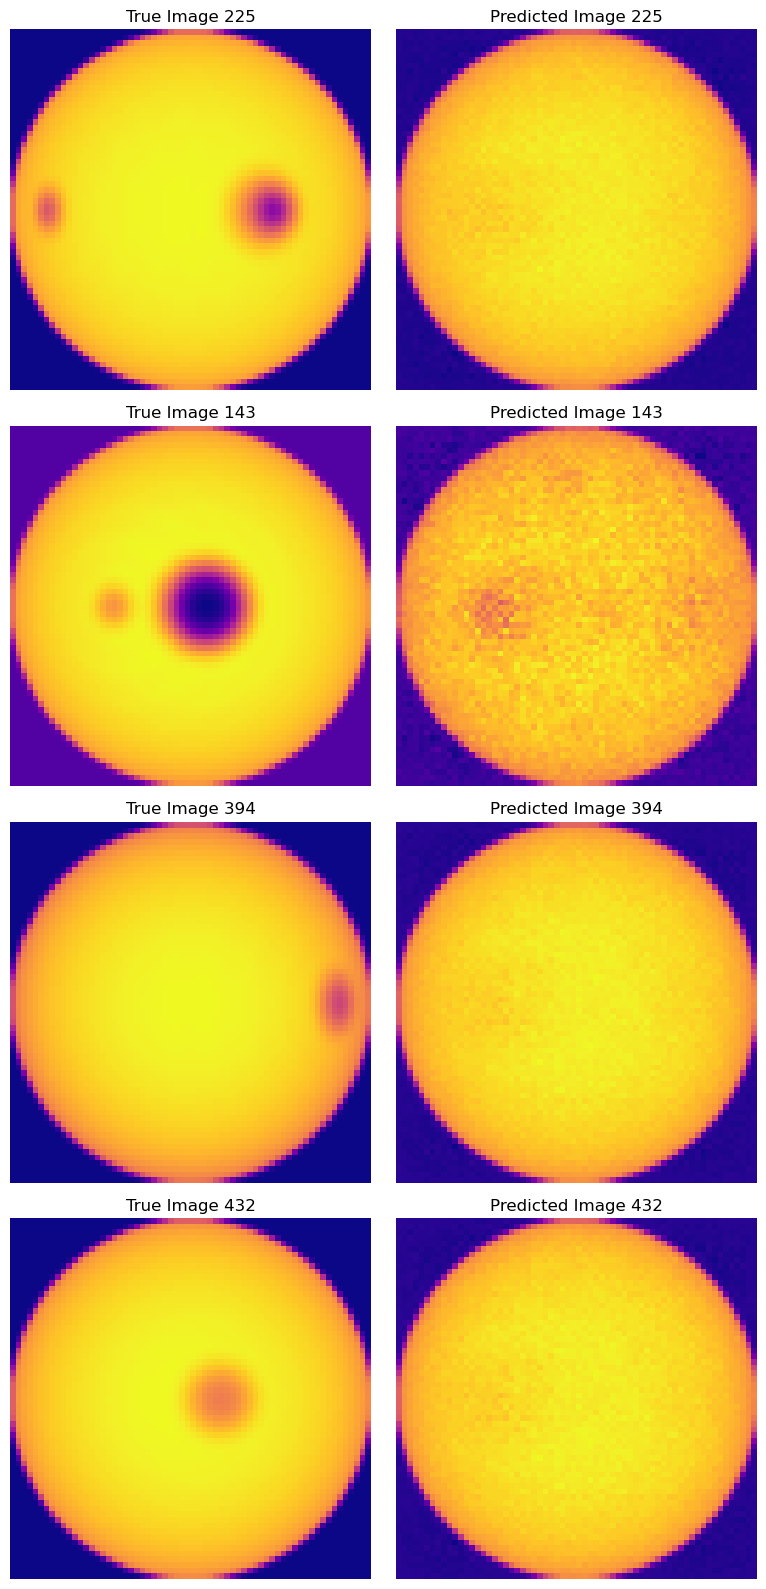

In [2]:
# Inference notebook for trained LC2Img model

import torch
import matplotlib.pyplot as plt
from data.dataset import StarryNPZDataset
from trainers.lc2img_module import LC2ImgModule
from torch.utils.data import DataLoader
import numpy as np
import os

# Paths and parameters (modify accordingly)
MODEL_PATH = './output/final_model.pt'
DATA_PATH = '/Users/pablom.perez/Desktop/MIT-PhD-macbook/starmap/starmap4astron/synthetic_data_output/dataset2/synthetic_starry_data_part_0.npz'
IMG_SIZE = 64
LATENT_CHANNELS = 256
GRID_SIZE = (8, 8)
BASE_CHANNELS = 64

# Load the trained model
model = LC2ImgModule(
    latent_channels=LATENT_CHANNELS,
    grid_size=GRID_SIZE,
    img_size=IMG_SIZE,
    base_channels=BASE_CHANNELS
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
model.eval()

# Load the dataset
dataset = StarryNPZDataset(
    path=DATA_PATH,
    lc_key='flux',
    img_key='image',
    img_size=IMG_SIZE
)

# Select 4 random examples
indices = np.random.choice(len(dataset), size=4, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(8, 16))

with torch.no_grad():
    for idx, data_idx in enumerate(indices):
        lc, true_img = dataset[data_idx]

        # Run inference
        pred_img = model(lc.unsqueeze(0)).squeeze().cpu().numpy()

        # Plot true image
        axes[idx, 0].imshow(true_img.squeeze(), cmap='plasma')
        axes[idx, 0].set_title(f"True Image {data_idx}")
        axes[idx, 0].axis('off')

        # Plot predicted image
        axes[idx, 1].imshow(pred_img.squeeze(), cmap='plasma')
        axes[idx, 1].set_title(f"Predicted Image {data_idx}")
        axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import json
import os
import matplotlib.pyplot as plt

LOSS_JSON_PATH = './output/losses.json'

# Load loss data from JSON file
if os.path.exists(LOSS_JSON_PATH):
    with open(LOSS_JSON_PATH, 'r') as f:
        loss_data = json.load(f)

    train_losses = loss_data["train_losses"]
    val_losses = loss_data["val_losses"]
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Loss JSON file not found at {LOSS_JSON_PATH}")
